In [1]:
import os
import re
import h5py
import numpy as np
from collections import defaultdict
import spikeinterface.extractors as se

In [2]:
import h5py
import numpy as np

filename = r"C:\Users\sjs93\Downloads\RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis.h5"
with h5py.File(filename, "r") as f:
    # View the structure/keys within the file
    print("Datasets:", list(f.keys()))

    # Access a specific dataset, e.g., 'tracks'
    # Data structure is typically (frames, nodes, x/y, instances) after transpose
    locations = f["tracks"][:].T 
    node_names = [n.decode() for n in f["node_names"][:]]
    print("Locations data shape:", locations.shape)
    print("Node names:", node_names)


Datasets: ['edge_inds', 'edge_names', 'instance_scores', 'labels_path', 'node_names', 'point_scores', 'provenance', 'track_names', 'track_occupancy', 'tracking_scores', 'tracks', 'video_ind', 'video_path']
Locations data shape: (9300, 8, 2, 2)
Node names: ['nose', 'head', 'left_ear', 'right_ear', 'middle', 'left_mid', 'right_mid', 'tail_base']


In [2]:
import sys
import os

# Add your script folder to Python's path
sys.path.append(r"C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion")

# Import your conversion function
from ekg_resp_to_h5 import convert_all_rec_to_h5



In [3]:
data_root = r"E:\Aim1\AIM1\Cagemate_bl_no_ISO"      # folder with .rec + .analog
output_dir = r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs"  # where to save .h5

convert_all_rec_to_h5(data_root, output_dir=output_dir)


Found 17 merged.rec files.


C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion\ekg_resp_to_h5.py:149: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return np.dtype(dtype_spec)


Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5
Exported: E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\CM_s2_3_d2_4_202

In [4]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Path to your h5 outputs
data_root = r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs"

# Grab all .h5 files
files = [f for f in os.listdir(data_root) if f.endswith(".h5")]
print(f"Found {len(files)} files in {data_root}")


Found 17 files in E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs


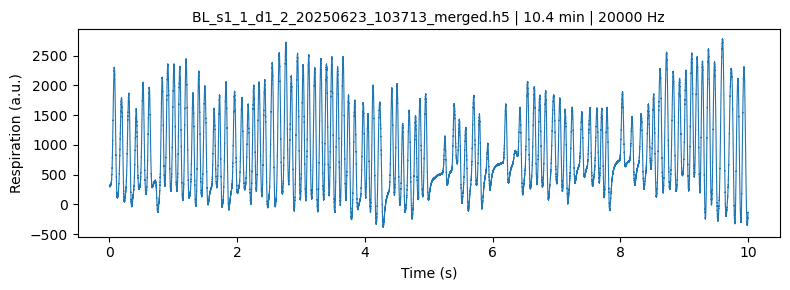

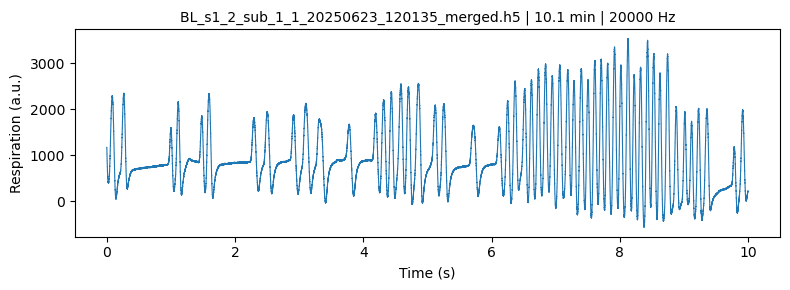

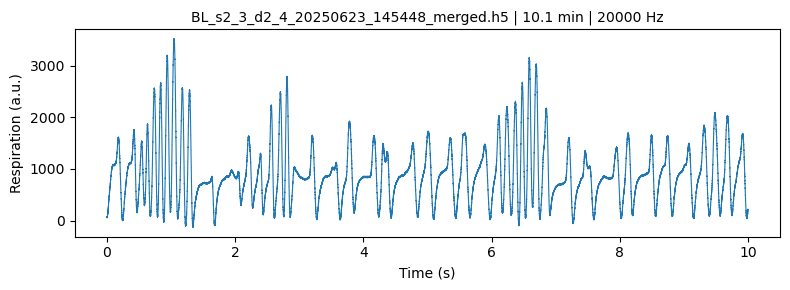

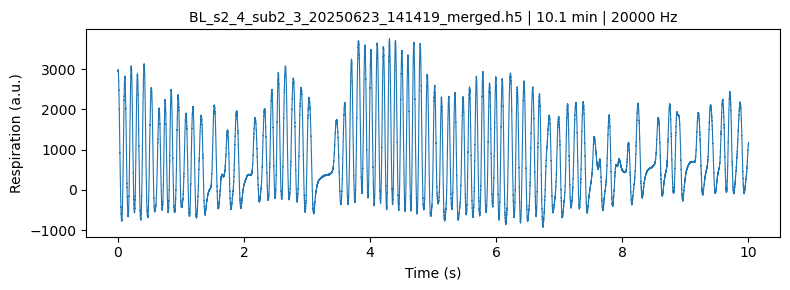

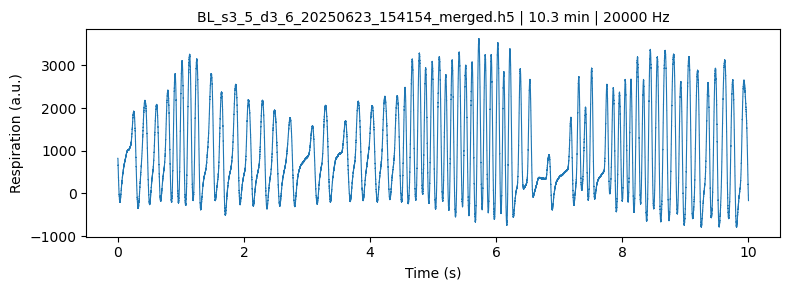

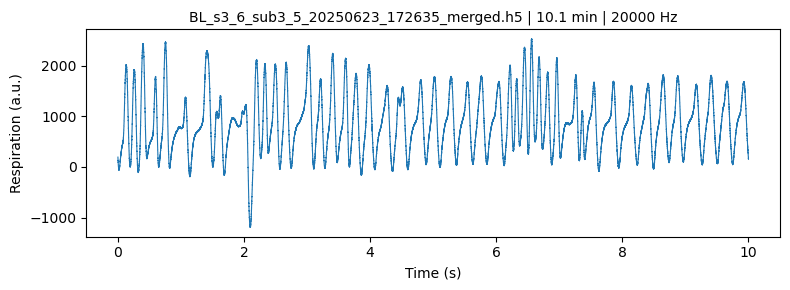

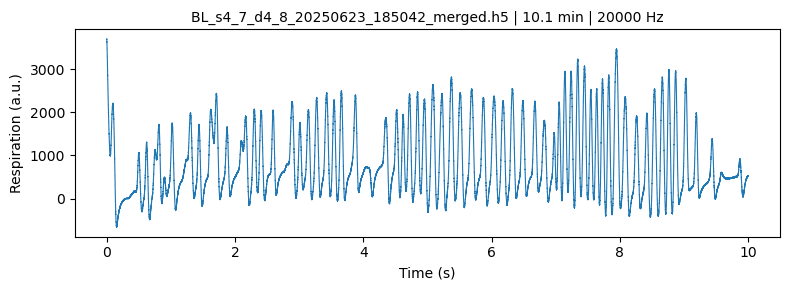

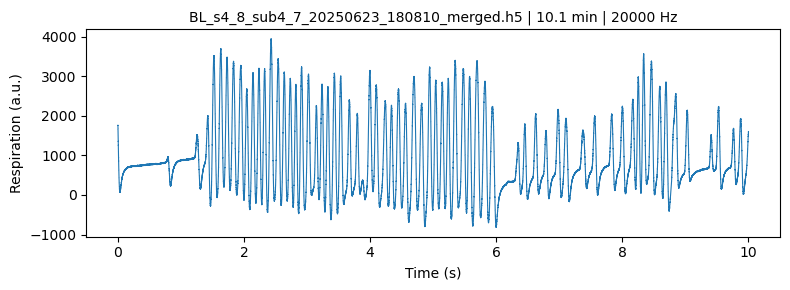

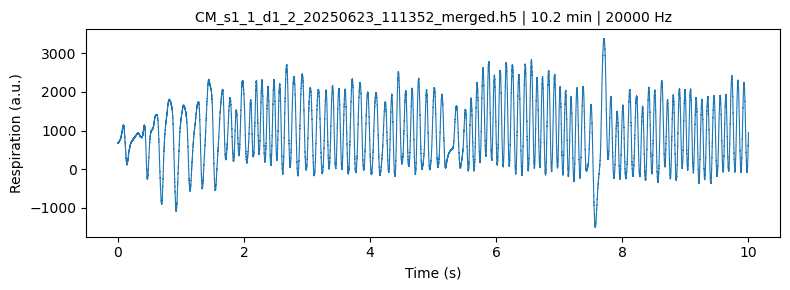

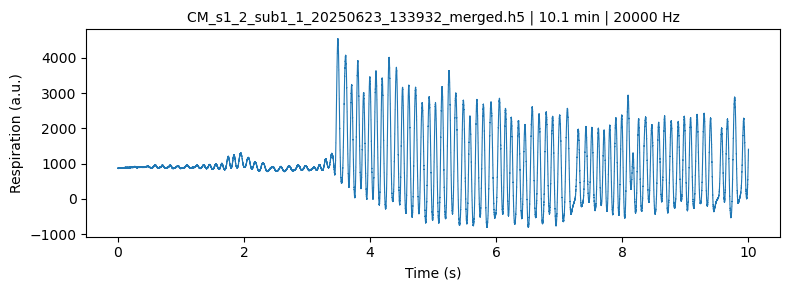

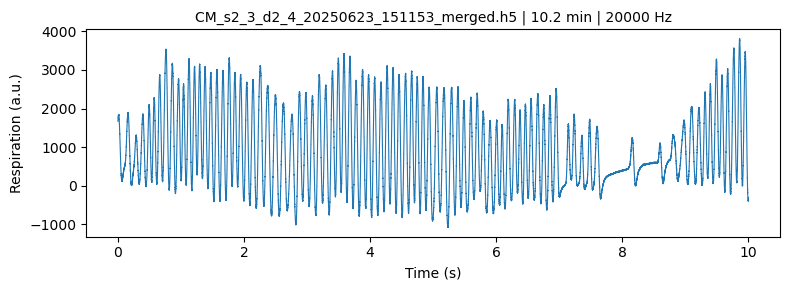

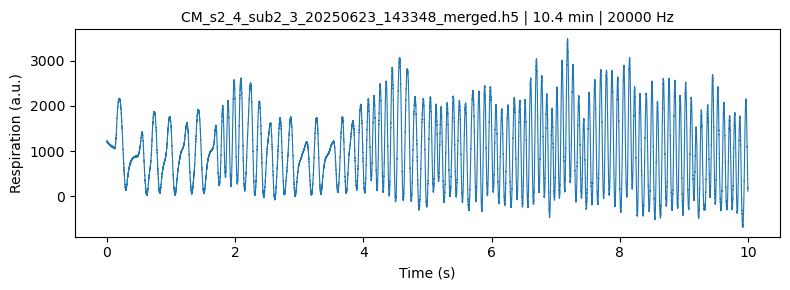

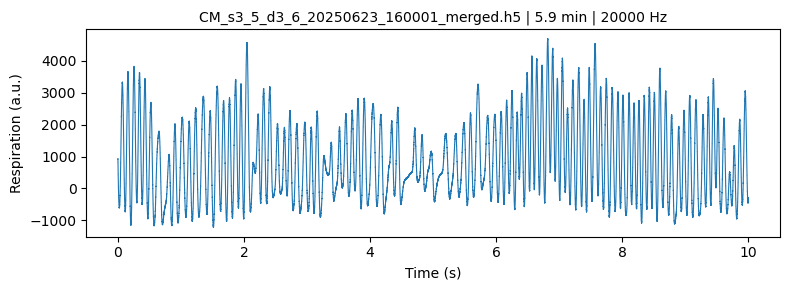

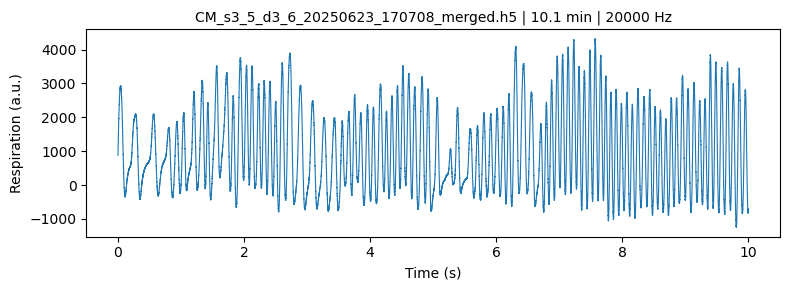

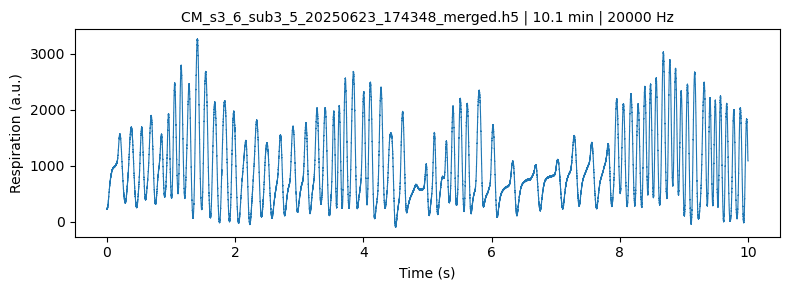

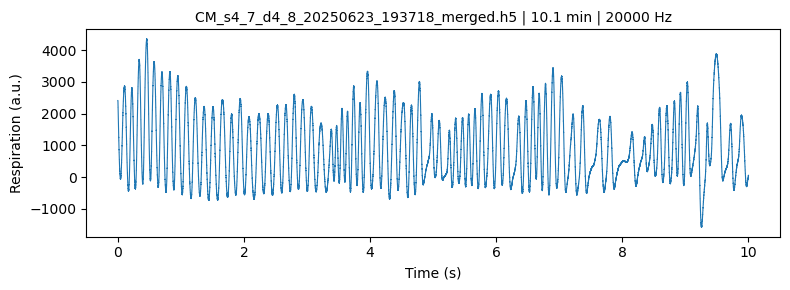

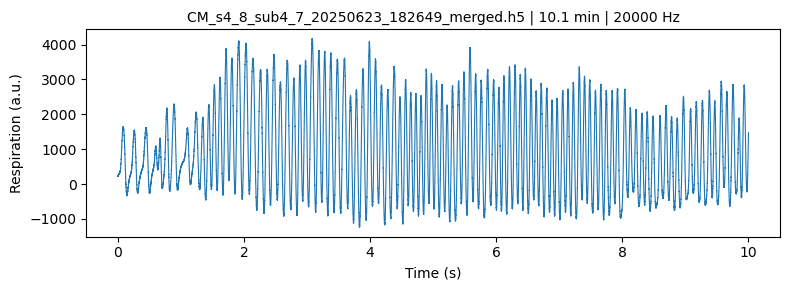

In [5]:
for f in files:
    full_path = os.path.join(data_root, f)
    with h5py.File(full_path, "r") as h5:
        if "resp" not in h5:
            print(f"⚠️ Skipping {f} (no resp dataset)")
            continue
        
        resp = h5["resp"][:]
        sr = h5["resp_metadata"].attrs["sampling_frequency"]
        duration = len(resp) / sr
        time = np.arange(len(resp)) / sr
        
        # --- Plot first 10 seconds
        plt.figure(figsize=(8,3))
        plt.plot(time[:int(sr*10)], resp[:int(sr*10)], linewidth=0.8)
        plt.title(f"{f} | {duration/60:.1f} min | {sr:.0f} Hz", fontsize=10)
        plt.xlabel("Time (s)")
        plt.ylabel("Respiration (a.u.)")
        plt.tight_layout()
        plt.show()
